# Claris: Histopathology Cancer Detector

This project was realized for Expo-Sciences hosted by Hydro-Quebec.

## Introduction

Many healthcare professionals are under great pressure with the current situation of Canadian healthcare industry. A severe lack of personnel is a prominent issue, and the efficiency in cancer diagnosis process is worsened by this problem. It is not always easy to detect cancer in images. This project aims to develop a deep learning model that can detect histopathologic cancer in images, in order to ease the process of detection and pressure on the healthcare industry.

---

## Dataset

https://www.kaggle.com/competitions/histopathologic-cancer-detection/data 

This dataset of histopathologic scans of lymph node sections is a modified version of the PCAM (PatchCamelyon) dataset.

> 
    The PatchCamelyon benchmark (PCAM) consists of 327.680 color images (96 x 96px) extracted from histopathologic scans of lymph node sections. Each image is annoted with a binary label indicating presence of metastatic tissue.
    Fundamental machine learning advancements are predominantly evaluated on straight-forward natural-image classification datasets and medical imaging is becoming one of the major applications of ML and thus deserves a spot on the list of go-to ML datasets. Both to challenge future work, and to steer developments into directions that are beneficial for this domain.


## Model

The final model chosen for the product is ResNet-50, an architecture of Convolutional Neural Network (CNN) that excels in both precision and training & inference speed, rendering it the optimal choice for maximum efficiency while not sacrificing accuracy. The model's output layer consists of two neurons: benign or malignant.

## Implementation

This implementation utilizes PyTorch. The model is trained on Kaggle duo-T4 GPU.
  
## Accuracy
The model achieved a peak accuracy of around **98.30%** after 20 epochs.

## Sources
Thanks to many Kaggle competitions, datasets and notebooks for inspiration.

### 1) Imports and configuration

In [88]:
# Import useful libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns


#### Setting up the environment
Using Kaggle's Nvidia GPU 

In [89]:
# Device -> Nvidia GPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # Use GPU cuda if available
print('Using device:', DEVICE)

# Config for images
IMG_SIZE = 96
BATCH_SIZE = 64
NUM_WORKERS = 8

Using device: cuda


### 2) Data transformations
Diversify the training data by augmenting the images with random rotations, flips, and translations.

In [90]:
# Train data transformations
#  - Augmented to increase diversity of the dataset
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),            # Ensure consistent size
    transforms.RandomHorizontalFlip(),                  # Random flips (augmentation)
    transforms.RandomVerticalFlip(),                    # Random flips  (augmentation)
    transforms.RandomRotation(20),                      # Random rotations (augmentation)
    transforms.ToTensor(),                              # Convert to tensor
    transforms.Normalize(                               # Standardize pixel values
        mean=[0.485, 0.456, 0.406],  # ImageNet mean
        std=[0.229, 0.224, 0.225]    # ImageNet std
    )
])

# Test data transformations (no augmentation or randomness)
val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### 3) Data loading helper class


In [ ]:
class Dataset(Dataset):
    """
    Dataset for Kaggle Histopathologic Cancer Detection (based on PCAM)
    Uses .tif images + train_labels.csv
    """

    def __init__(self, img_dir, csv_path, transform=None):
        self.img_dir = img_dir
        self.transform = transform
    
        self.df = pd.read_csv(csv_path) # train_labels.csv

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.iloc[idx, 0]          # image id
        label  = int(self.df.iloc[idx, 1])     # 0 or 1 (cancer or not)

        # Load image and convert pixel data to RGB values
        img_path = os.path.join(self.img_dir, img_id + ".tif")
        image = Image.open(img_path).convert("RGB")

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        return image, label


### 4) Load PCam dataset


In [92]:
# Kaggle directory (PCam)
BASE_DIR = "/kaggle/input/competitions/histopathologic-cancer-detection/"

TRAIN_DIR = BASE_DIR + "train"
CSV_PATH = BASE_DIR + "train_labels.csv"

# Read in the CSV file
df = pd.read_csv(CSV_PATH)

# Split into train and validation datasets
train_df, val_df = train_test_split(
    df,
    test_size=0.2,          # 20% of the data will be used for validation
    stratify=df["label"],   # Ensure that the validation set has similar distribution to the training set
    random_state=42
)

# Save the split datasets to CSV files
train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv", index=False)


#### Data loaders


In [93]:
# Batch per step for parallel training
BATCH_SIZE = 128

train_dataset = Dataset(
    TRAIN_DIR, "train_split.csv", train_tfms
)

val_dataset = Dataset(
    TRAIN_DIR, "val_split.csv", val_tfms
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True, # faster GPU data transfer
    persistent_workers=True, # keep warm state for >1 epoch
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    persistent_workers=True,
    num_workers=NUM_WORKERS
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


### 5) Loading ResNet-50 model
The model has been pre-trained on ImageNet (Transfer learning). <br>
Hence, the model already knows how to detect edges, textures, patterns, colors, etc.


In [94]:
# Load pretrained Resnet50 from torchvision
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Replace the classifier layer (fully connected layer)
# ResNet outputs 2048 features → we need 2 classes for benign / malignant
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

# Wrap for multi-GPU
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = torch.nn.DataParallel(model) # parallel computing
    
model = model.to(DEVICE)

print("===========================================RESNET-50 ARCHITECTURE===========================================")
print(model)
print("============================================================================================================")

# If model exists, load it
if os.path.exists("./claris_resnet-50.pth"):
    model.load_state_dict(torch.load("./claris_resnet-50.pth"))
    print(f"Successfully loaded saved model ResNet-50")
else:
    print("No saved model found. Training from scratch.")


Using 2 GPUs!
===========================================RESNET-50 ARCHITECTURE===========================================
DataParallel(
  (module): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momen

#### Loss function and optimizer

In [95]:
# Class imbalance handling
class_weights = torch.tensor([1.0, 1.5]).to(DEVICE)

# Binary classification
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Prevent underflow (~0 gradient rounded to 0)
scaler = torch.amp.GradScaler() 

### 6) Training the model


In [96]:
def train_one_epoch(model, loader):
    
    model.train()  # enable training mode
    running_loss = 0.0
    correct = 0
    total = 0
    
    loop = tqdm(loader, total=len(train_loader), desc="Training")

    for images, labels in loop:
        # Move data to device (GPU)
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        # Reset gradients
        optimizer.zero_grad()
        
        # Mixed precision training for faster training
        # COMPARE RESULTS AND PENALIZE LOSS
        with torch.amp.autocast("cuda"):
            # Forward pass (prediction results)
            outputs = model(images)
            # Compute loss
            loss = criterion(outputs, labels)

        # Backpropagation (how should each weight change to make the loss smaller?)
        scaler.scale(loss).backward() # loss.backward()

        # Update weights for real
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        
        # Compute accuracy
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        train_acc = correct / total
        
        # Update progress bar
        loop.set_postfix(loss=running_loss / (loop.n+1))
        
    print(f"Trained {correct} correct out of {total}")

    return running_loss / len(loader), train_acc


#### Validation

In [97]:
def validate(model, loader):
    model.eval()  # evaluation mode
    correct = 0
    total = 0
    
    # Lists to store all predicitons and actual labels for the entire epoch
    all_predictions = []
    all_labels = []

    # Disable gradients in inference mode
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating", leave=False): # Progress bar
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            # Keep track of the total number of correct predictions and total predictions
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            # Move tensors back to CPU and add to our lists
            all_predictions.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # Calculate metrics
    acc = accuracy_score(all_labels, all_predictions)
    prec = precision_score(all_labels, all_predictions, zero_division=0)
    rec = recall_score(all_labels, all_predictions, zero_division=0)
    f1 = f1_score(all_labels, all_predictions, zero_division=0)
    cm = confusion_matrix(all_labels, all_predictions)

    # Print out the results
    print(f"Validation -> Acc: {acc*100:.2f}% | Precision: {prec*100:.2f}% | Recall: {rec*100:.2f}% | F1: {f1:.4f}")
    
    # Plot the Confusion Matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Benign (0)', 'Malignant (1)'], 
                yticklabels=['Benign (0)', 'Malignant (1)'])
    plt.ylabel('Réelle')
    plt.xlabel('Prédite')
    plt.title('Matrice de confusion')
    plt.show()

    return acc



### 7) Visualizing prediction results


In [98]:
# Plotting for visualization

def plot_validation_accuracy(val_history):
    epochs = range(1, len(val_history) + 1)

    plt.figure(figsize=(10, 6))
    # Plot only the validation data
    plt.plot(epochs, val_history, marker='s', linestyle='-', color='r', label='Exactitude de validation')
    
    plt.title("Évolution de l'exactitude de ResNet-50 en fonction des epochs (Validation)")
    plt.xlabel('Epochs')
    plt.ylabel('Exactitude (%)')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    
def plot_training_accuracy(train_history):
    epochs = range(1, len(train_history) + 1)
    
    plt.figure(figsize=(10, 6))
    # Plot only the training data
    plt.plot(epochs, train_history, marker='s', linestyle='-', color='b', label='Exactitude d\'entraînement')
    
    plt.title("Évolution de l'exactitude de ResNet-50 en fonction des epochs (Entraînement)")
    plt.xlabel('Epochs')
    plt.ylabel('Exactitude (%)')
    plt.legend()
    plt.grid(True)
    plt.show()



Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 160487 correct out of 176020


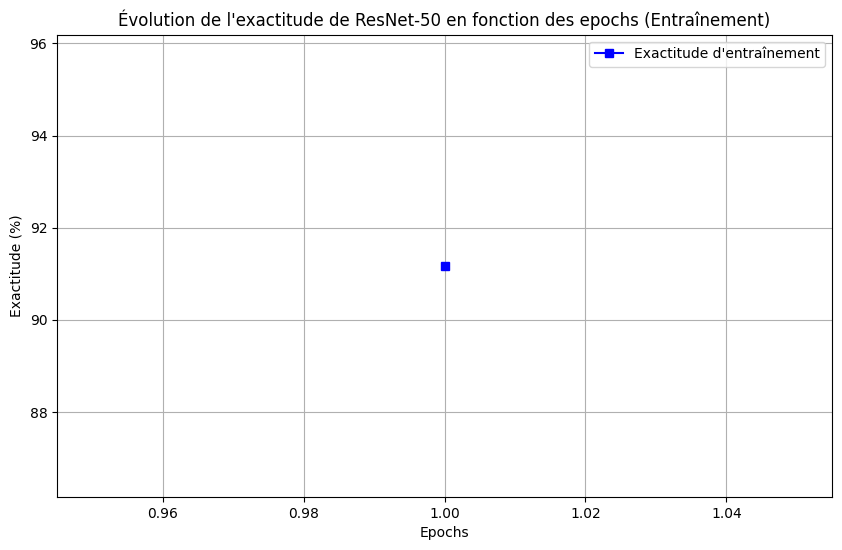

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 94.18% | Precision: 89.93% | Recall: 96.44% | F1: 0.9307


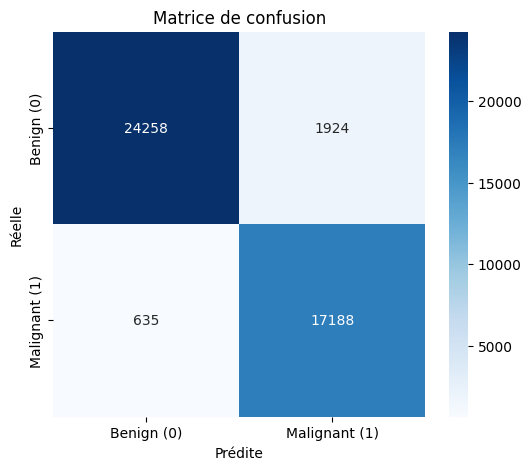

Epoch [1/30] Train Loss: 0.2211 | Train Acc: 91.18% | Val Acc: 94.18% 


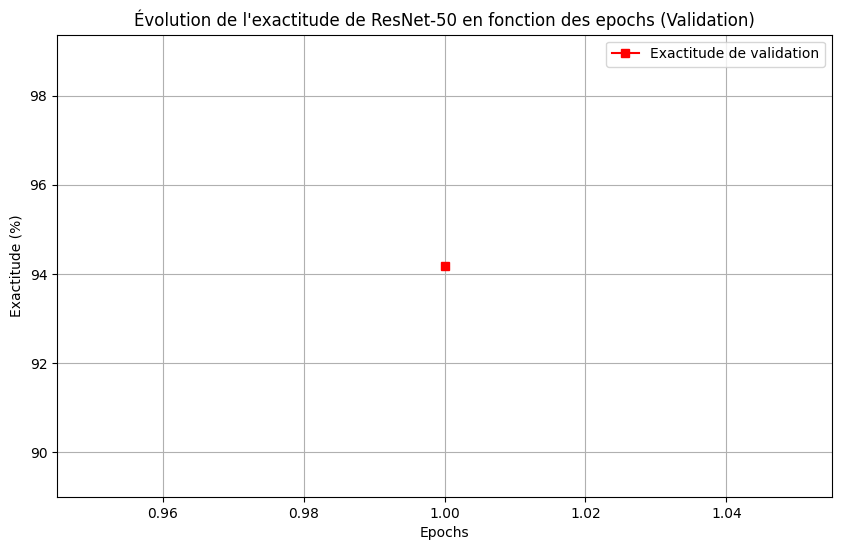

✓ Model saved with 94.18% accuracy


Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 167108 correct out of 176020


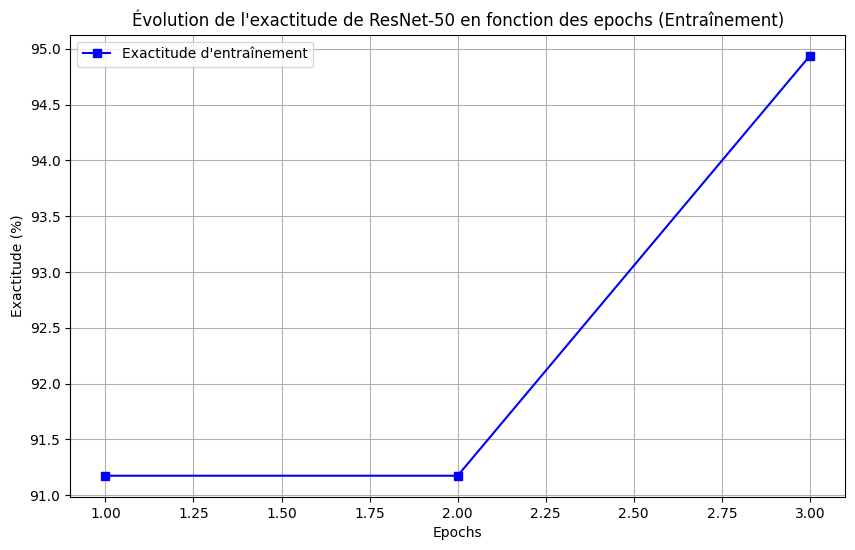

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 96.65% | Precision: 96.32% | Recall: 95.39% | F1: 0.9585


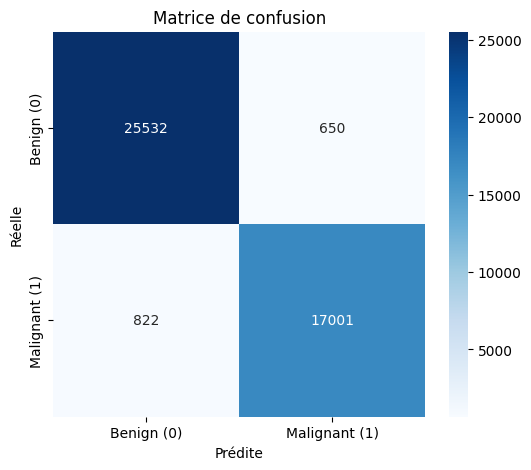

Epoch [2/30] Train Loss: 0.1373 | Train Acc: 94.94% | Val Acc: 96.65% 


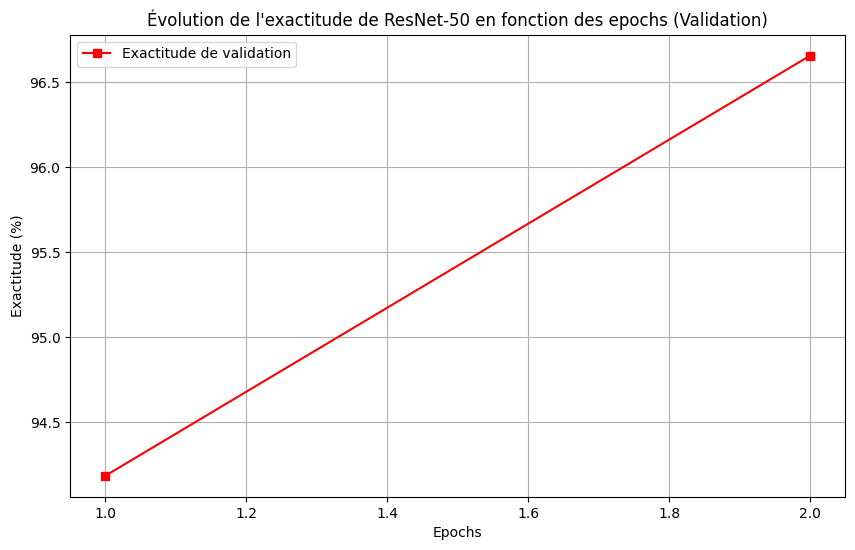

✓ Model saved with 96.65% accuracy


Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 168872 correct out of 176020


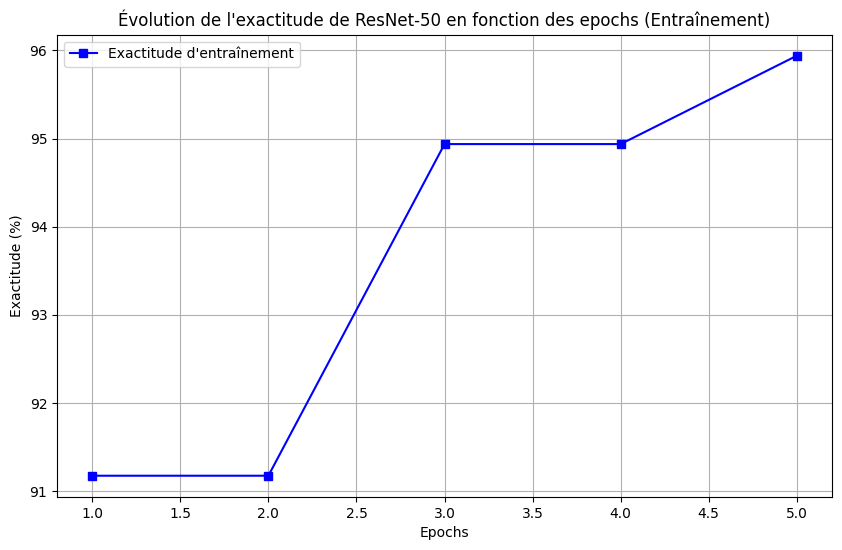

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 96.98% | Precision: 96.13% | Recall: 96.41% | F1: 0.9627


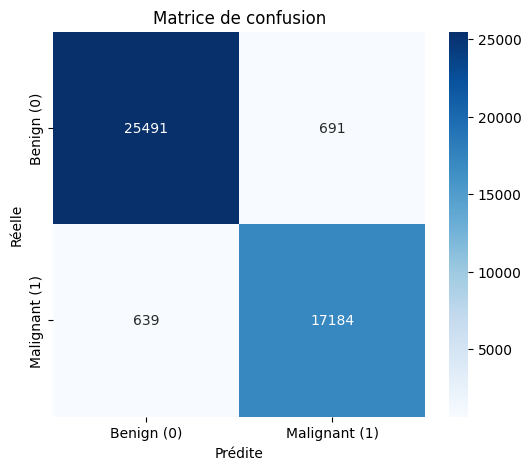

Epoch [3/30] Train Loss: 0.1136 | Train Acc: 95.94% | Val Acc: 96.98% 


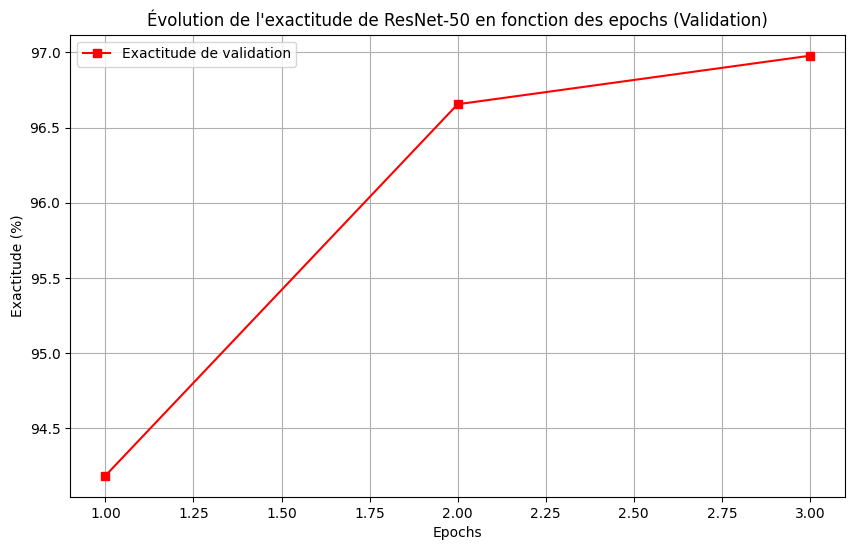

✓ Model saved with 96.98% accuracy


Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 169734 correct out of 176020


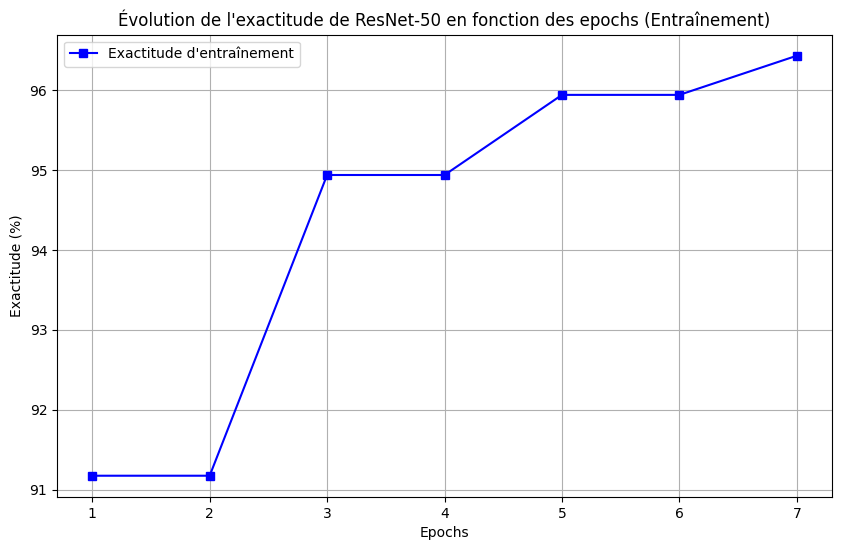

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 96.85% | Precision: 95.17% | Recall: 97.16% | F1: 0.9615


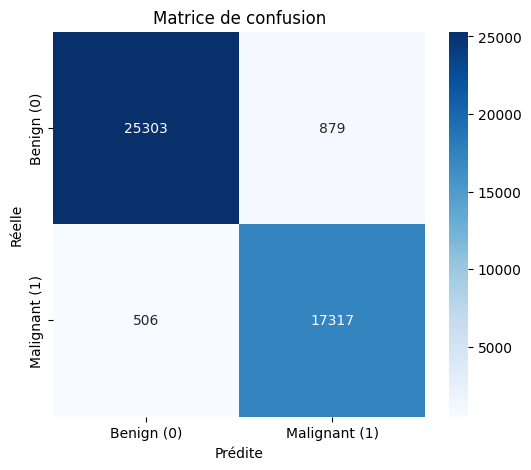

Epoch [4/30] Train Loss: 0.0989 | Train Acc: 96.43% | Val Acc: 96.85% 


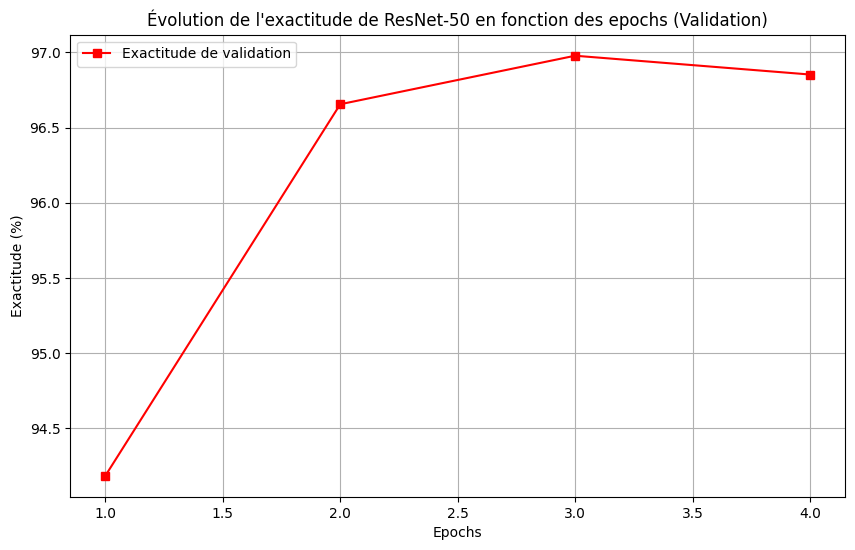

Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 170427 correct out of 176020


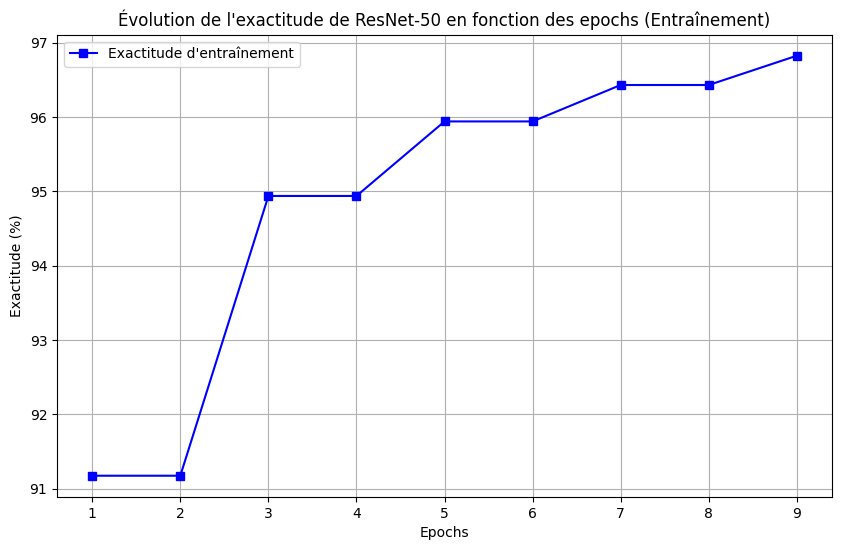

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 97.08% | Precision: 95.35% | Recall: 97.55% | F1: 0.9644


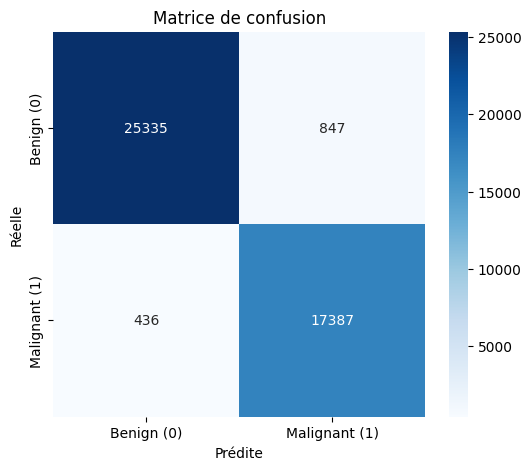

Epoch [5/30] Train Loss: 0.0885 | Train Acc: 96.82% | Val Acc: 97.08% 


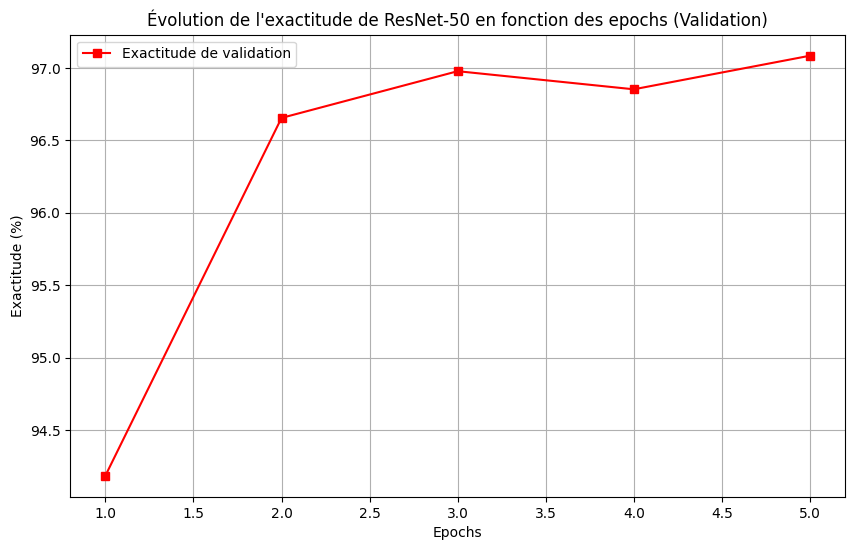

✓ Model saved with 97.08% accuracy


Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 171152 correct out of 176020


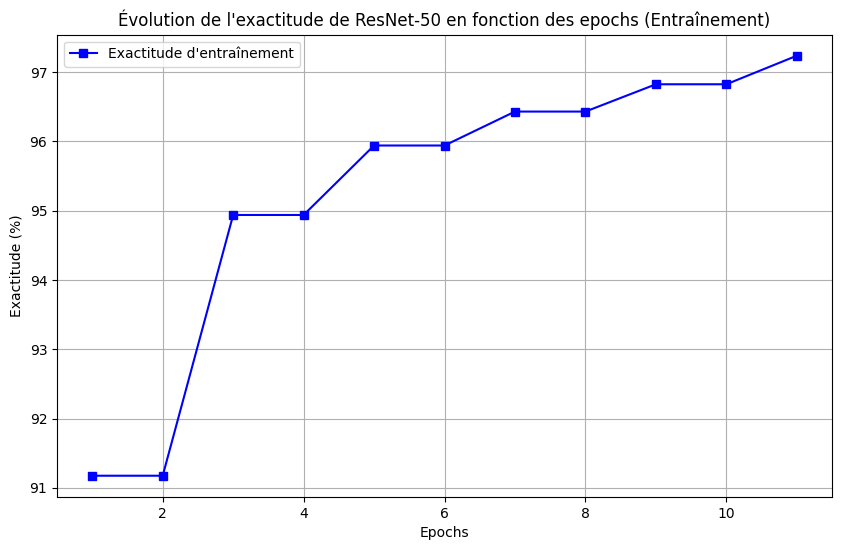

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 97.45% | Precision: 96.48% | Recall: 97.26% | F1: 0.9687


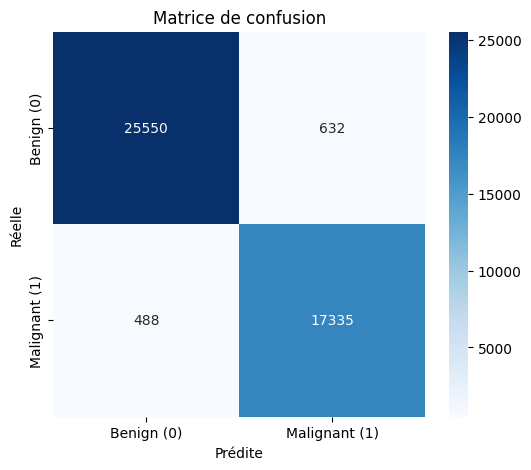

Epoch [6/30] Train Loss: 0.0785 | Train Acc: 97.23% | Val Acc: 97.45% 


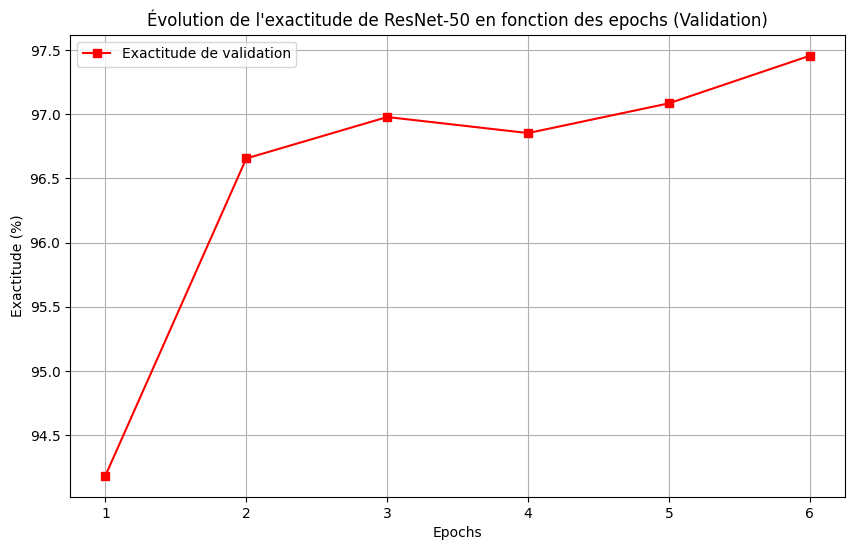

✓ Model saved with 97.45% accuracy


Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 171473 correct out of 176020


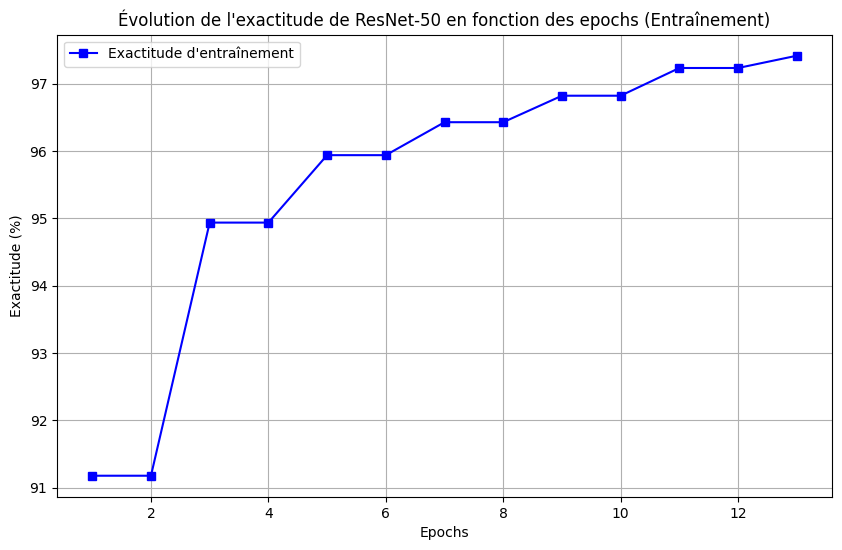

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 97.42% | Precision: 95.68% | Recall: 98.07% | F1: 0.9686


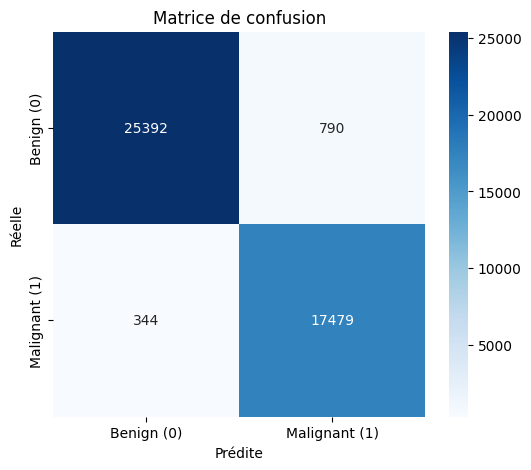

Epoch [7/30] Train Loss: 0.0716 | Train Acc: 97.42% | Val Acc: 97.42% 


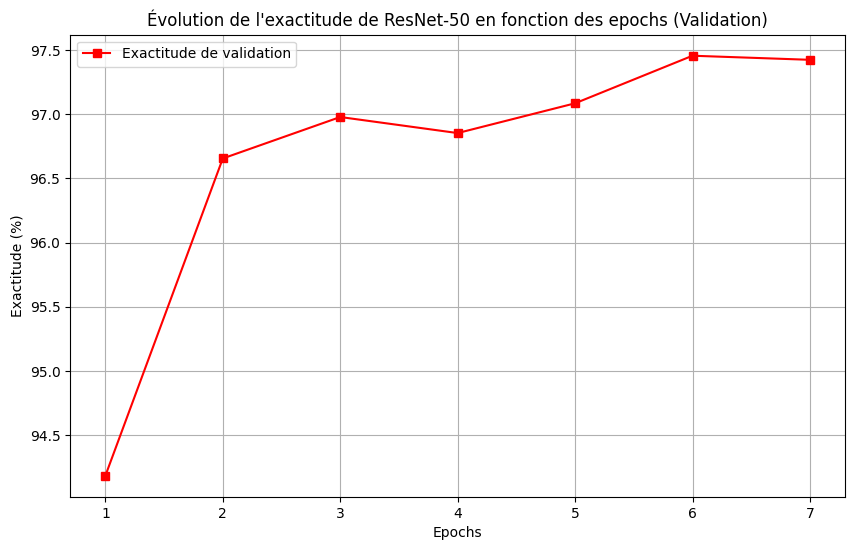

Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 171861 correct out of 176020


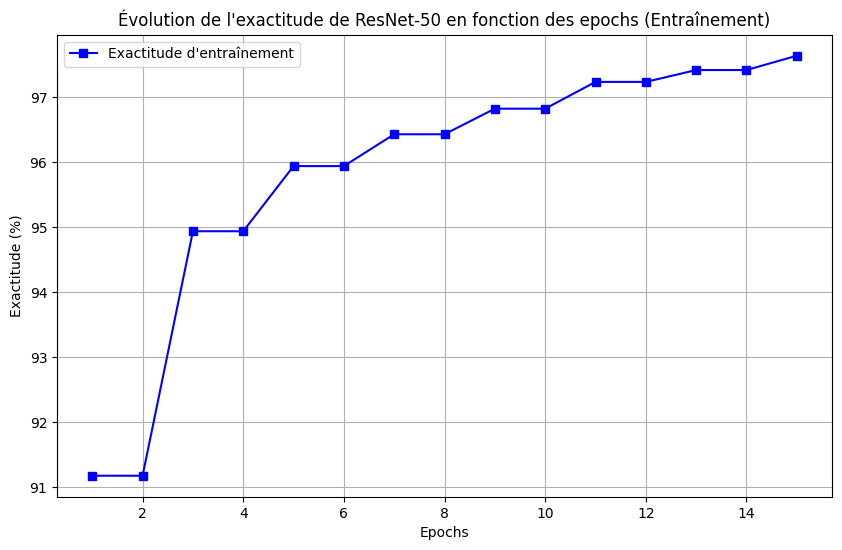

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 97.37% | Precision: 95.77% | Recall: 97.82% | F1: 0.9678


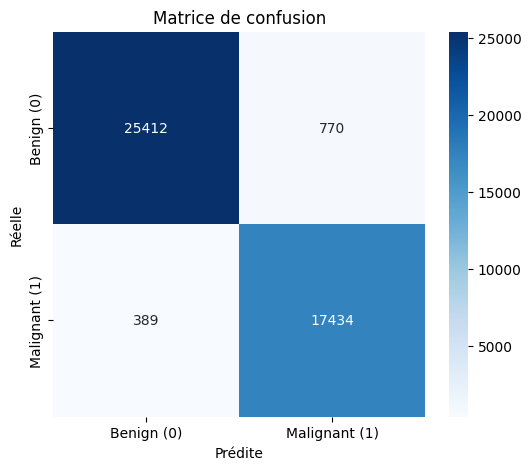

Epoch [8/30] Train Loss: 0.0662 | Train Acc: 97.64% | Val Acc: 97.37% 


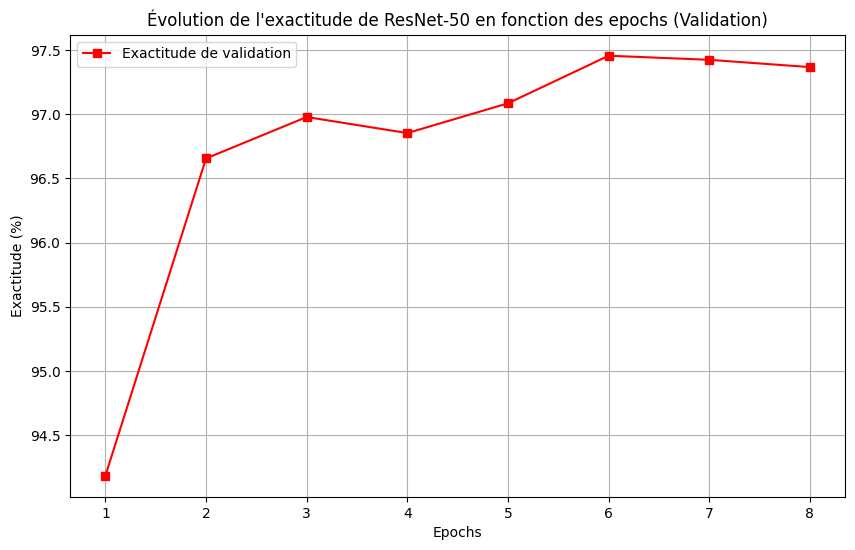

Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 172138 correct out of 176020


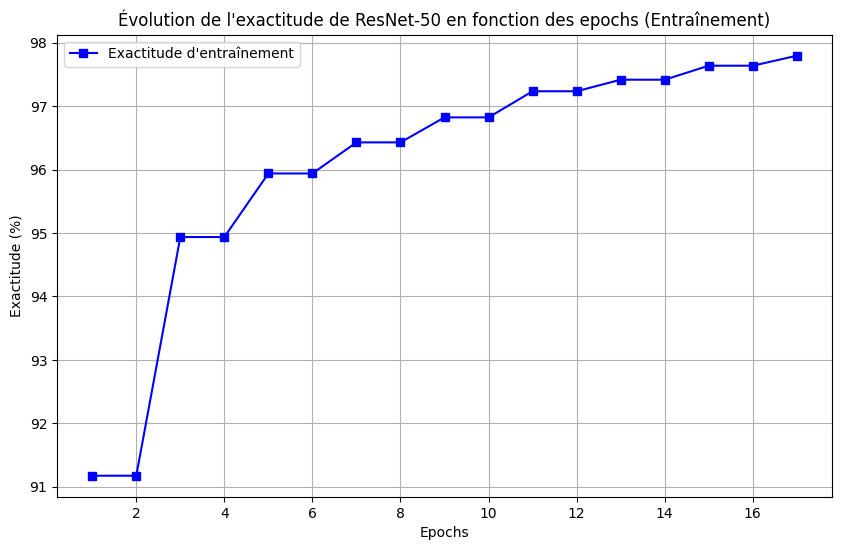

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 97.25% | Precision: 95.25% | Recall: 98.11% | F1: 0.9666


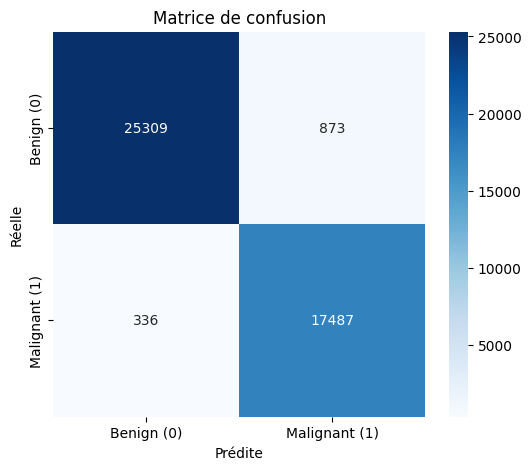

Epoch [9/30] Train Loss: 0.0618 | Train Acc: 97.79% | Val Acc: 97.25% 


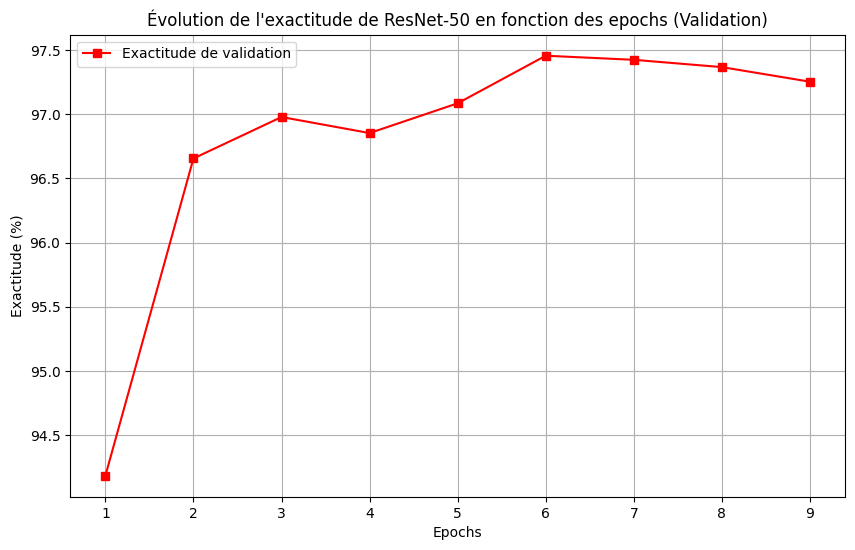

Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 172489 correct out of 176020


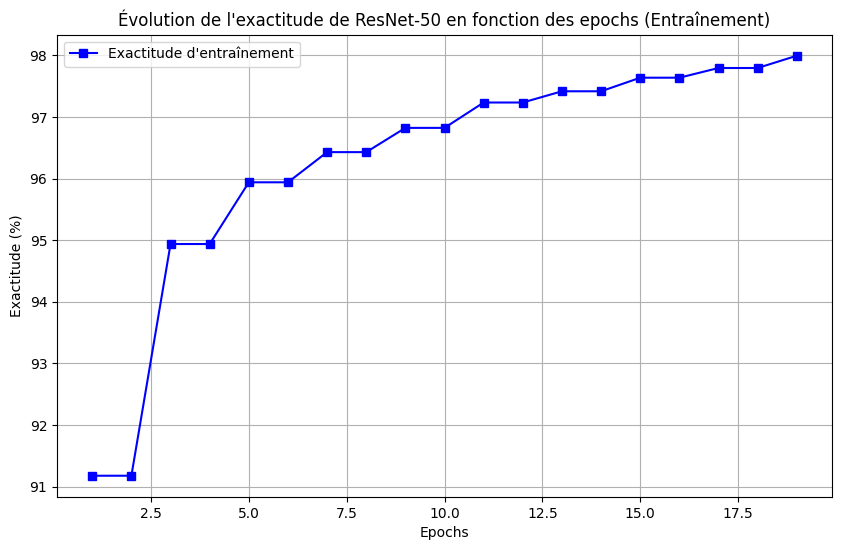

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 97.88% | Precision: 96.94% | Recall: 97.85% | F1: 0.9739


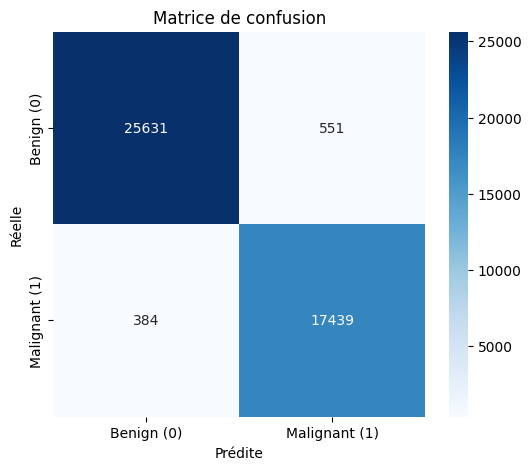

Epoch [10/30] Train Loss: 0.0566 | Train Acc: 97.99% | Val Acc: 97.88% 


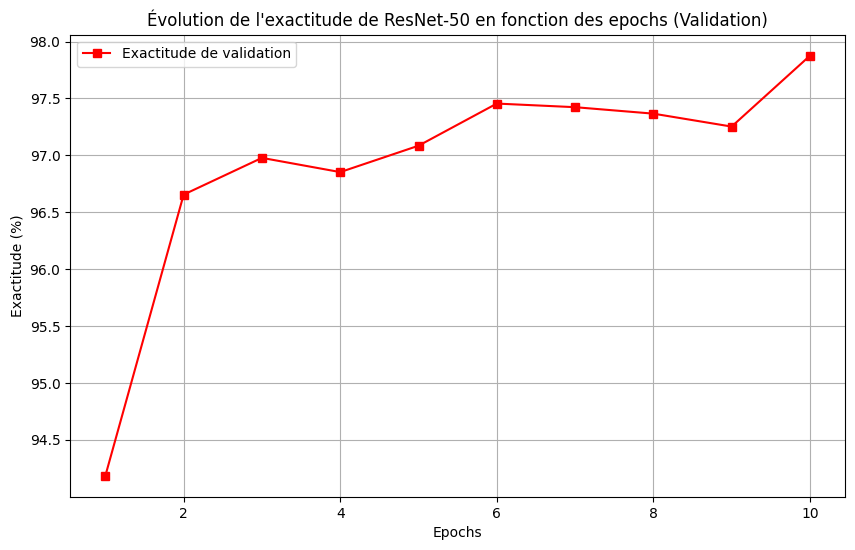

✓ Model saved with 97.88% accuracy


Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 172627 correct out of 176020


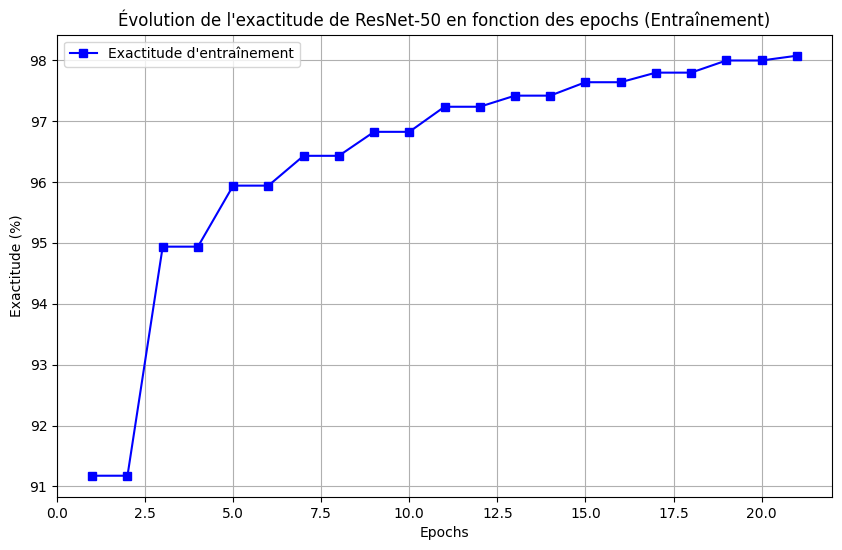

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 98.00% | Precision: 97.10% | Recall: 97.99% | F1: 0.9754


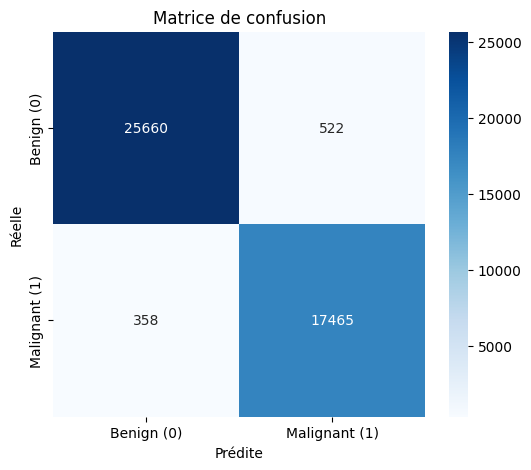

Epoch [11/30] Train Loss: 0.0529 | Train Acc: 98.07% | Val Acc: 98.00% 


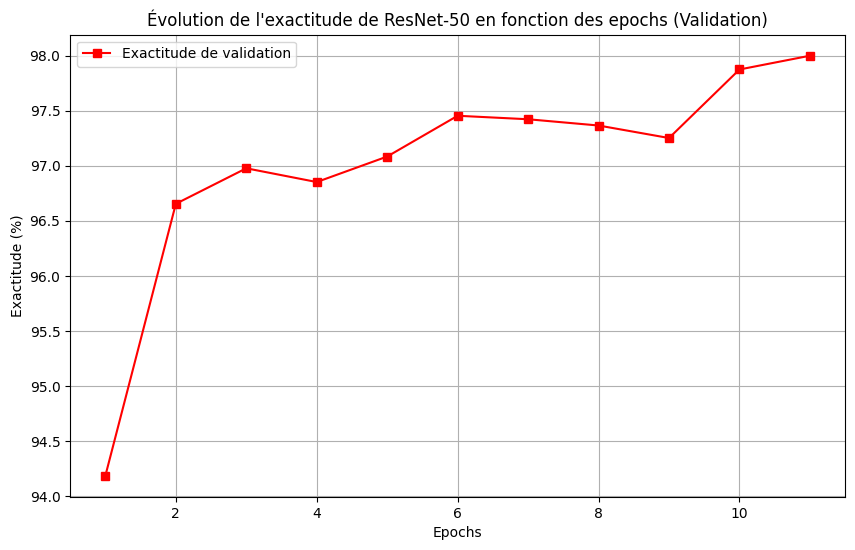

✓ Model saved with 98.00% accuracy


Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 172986 correct out of 176020


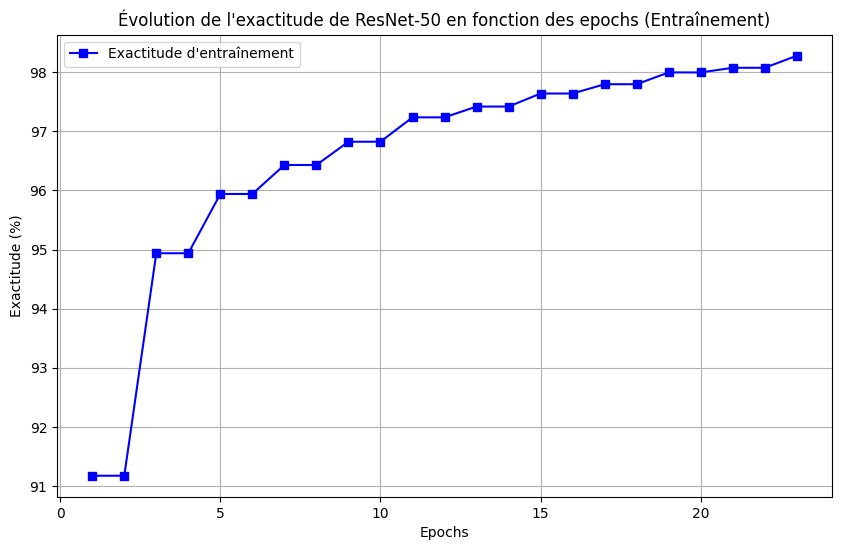

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 97.87% | Precision: 97.05% | Recall: 97.72% | F1: 0.9738


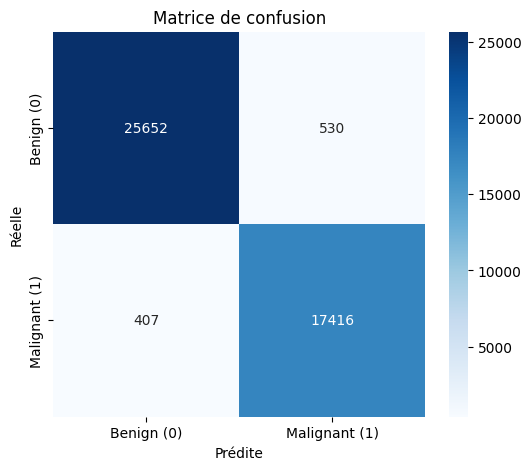

Epoch [12/30] Train Loss: 0.0487 | Train Acc: 98.28% | Val Acc: 97.87% 


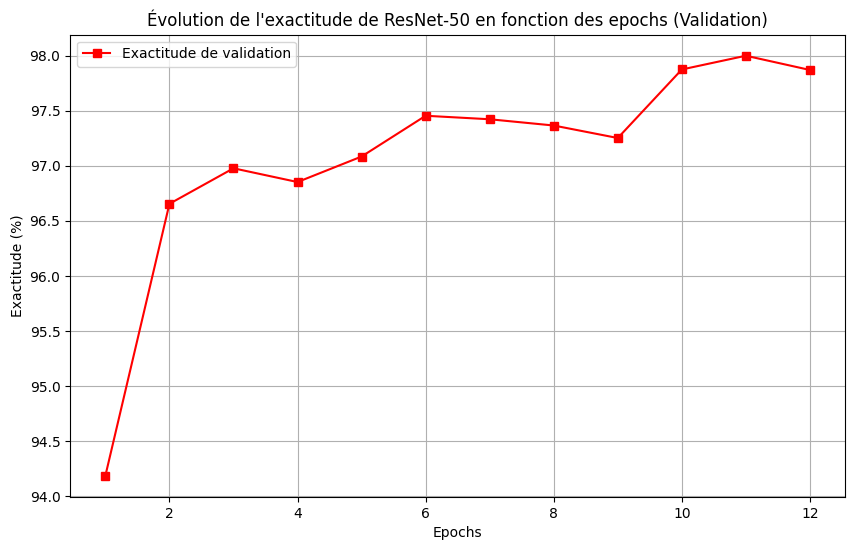

Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 173169 correct out of 176020


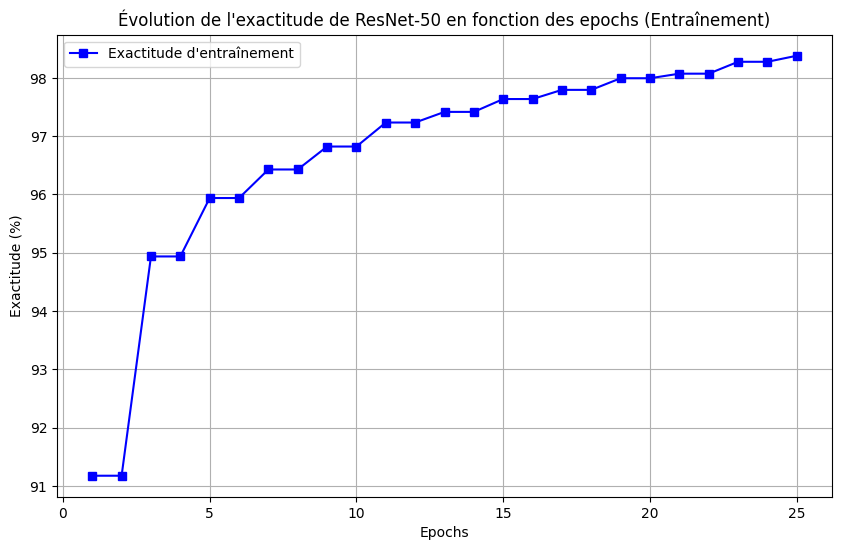

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 97.76% | Precision: 96.09% | Recall: 98.47% | F1: 0.9727


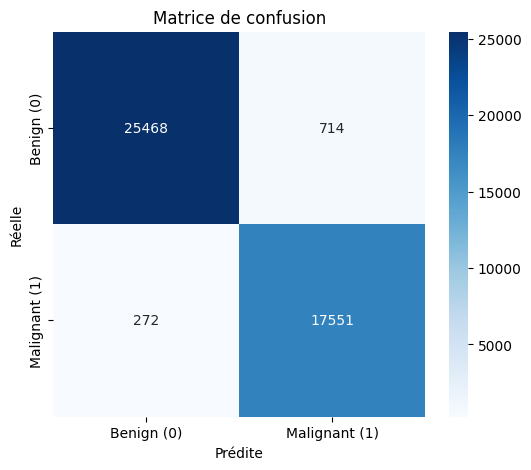

Epoch [13/30] Train Loss: 0.0457 | Train Acc: 98.38% | Val Acc: 97.76% 


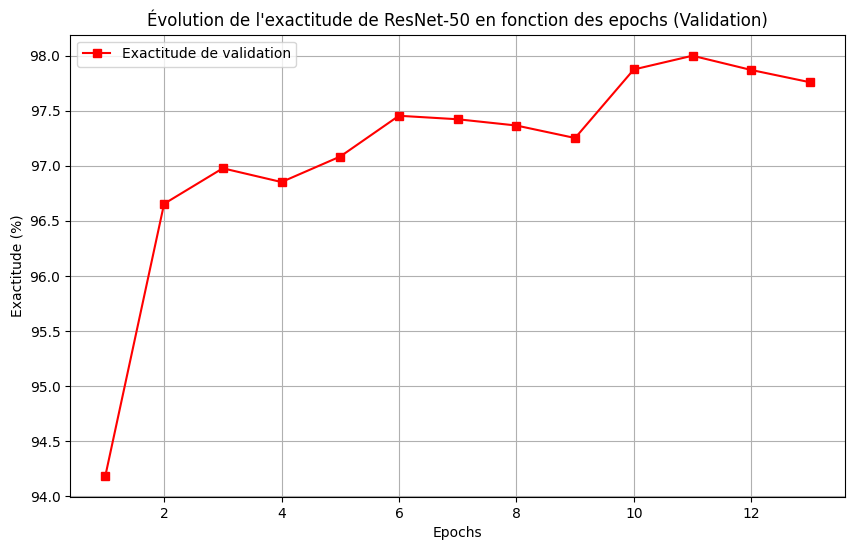

Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 173314 correct out of 176020


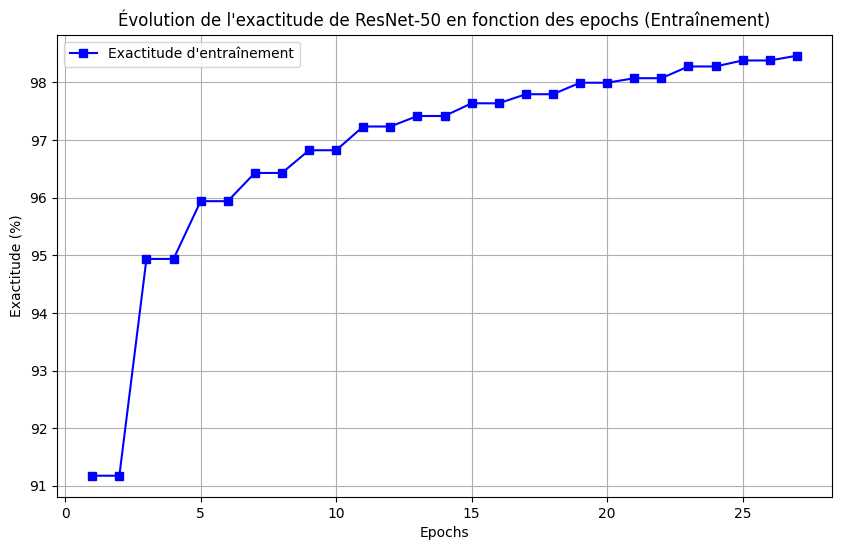

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 97.95% | Precision: 97.57% | Recall: 97.38% | F1: 0.9747


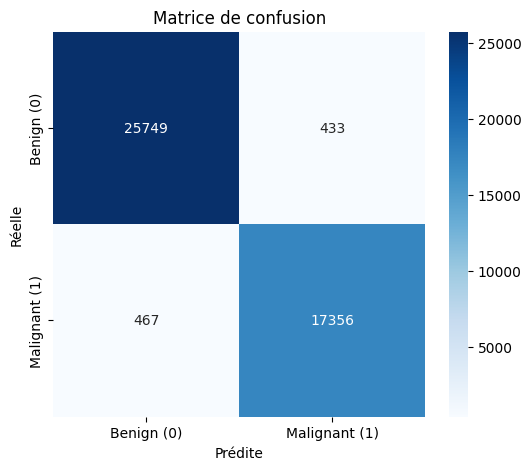

Epoch [14/30] Train Loss: 0.0430 | Train Acc: 98.46% | Val Acc: 97.95% 


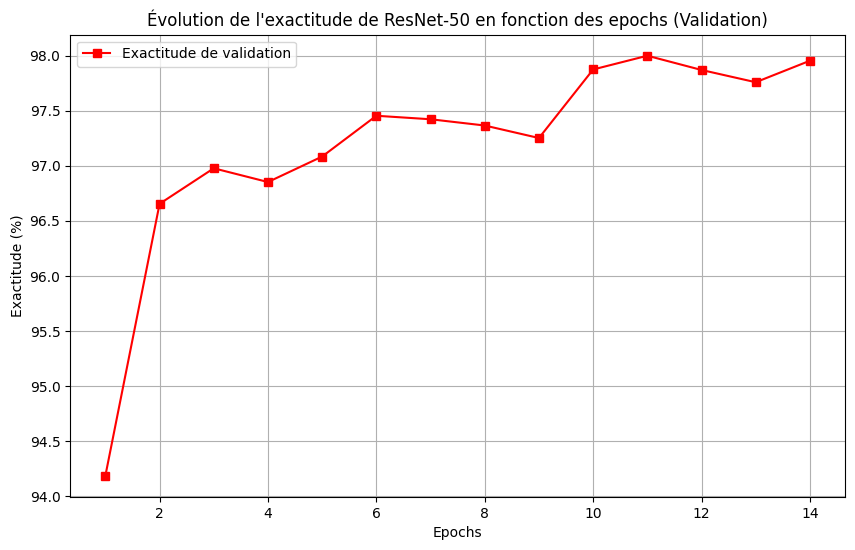

Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 173476 correct out of 176020


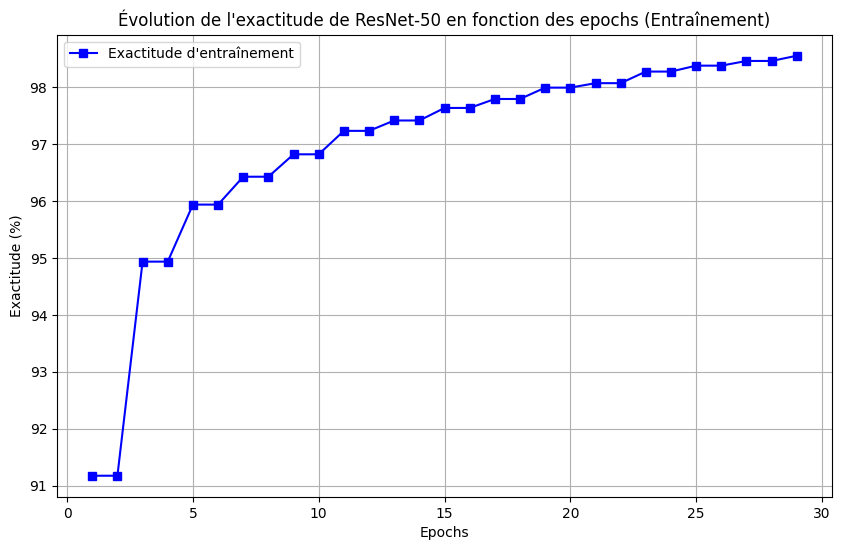

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 97.82% | Precision: 96.49% | Recall: 98.18% | F1: 0.9733


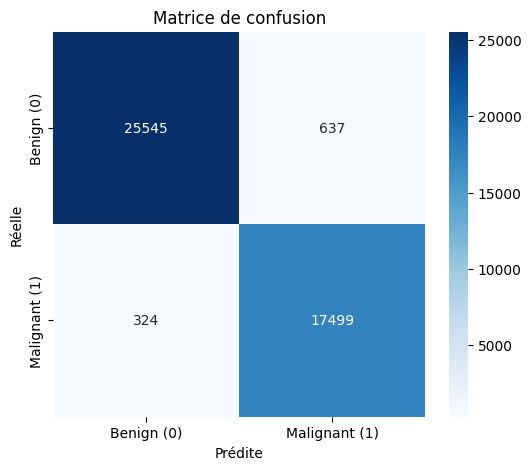

Epoch [15/30] Train Loss: 0.0397 | Train Acc: 98.55% | Val Acc: 97.82% 


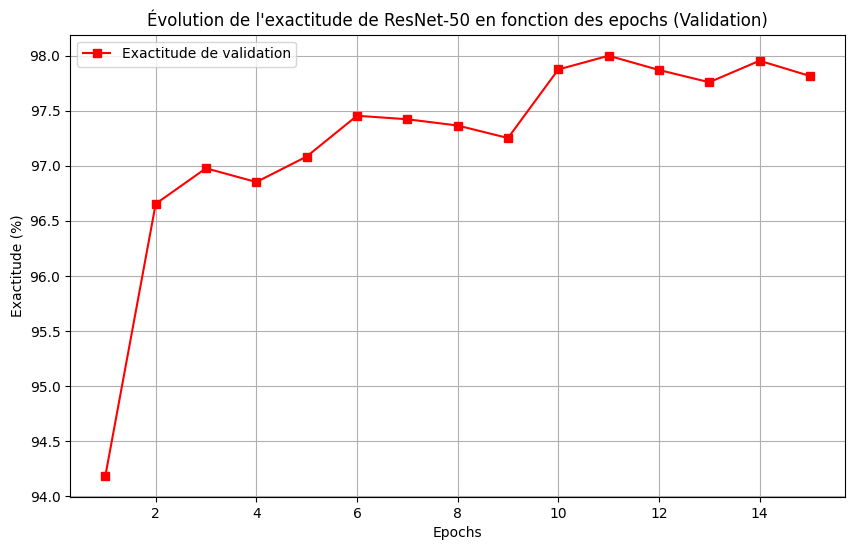

Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 173584 correct out of 176020


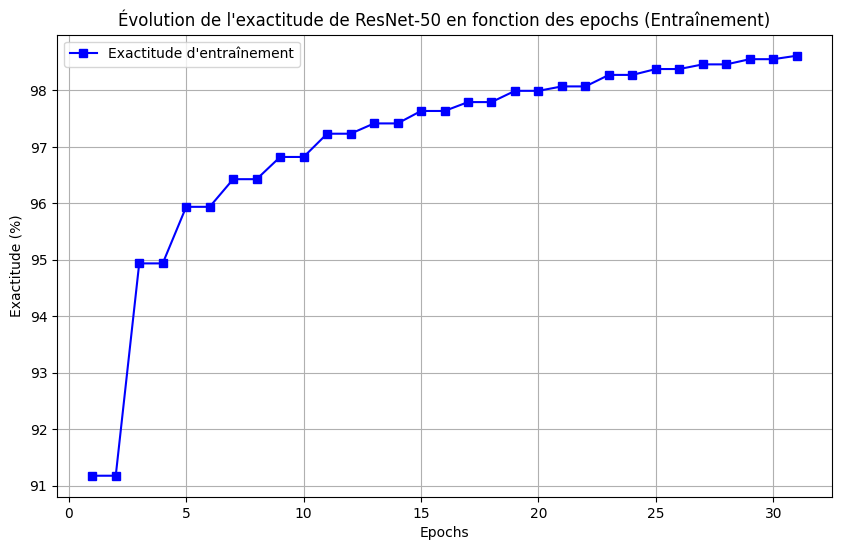

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 97.71% | Precision: 96.17% | Recall: 98.27% | F1: 0.9721


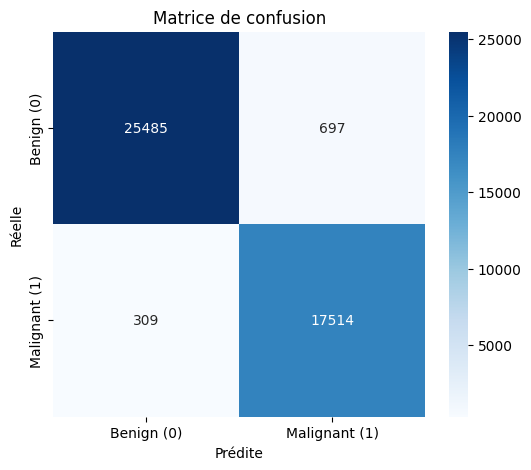

Epoch [16/30] Train Loss: 0.0381 | Train Acc: 98.62% | Val Acc: 97.71% 


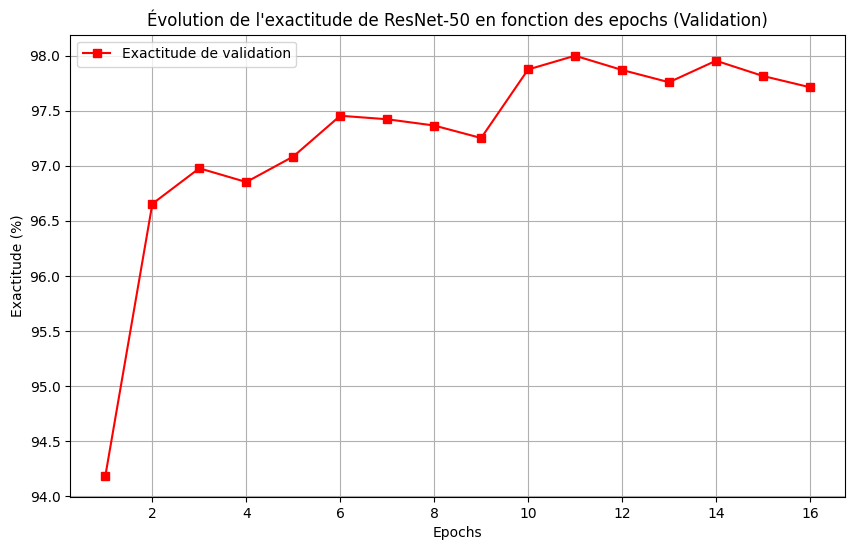

Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Trained 173764 correct out of 176020


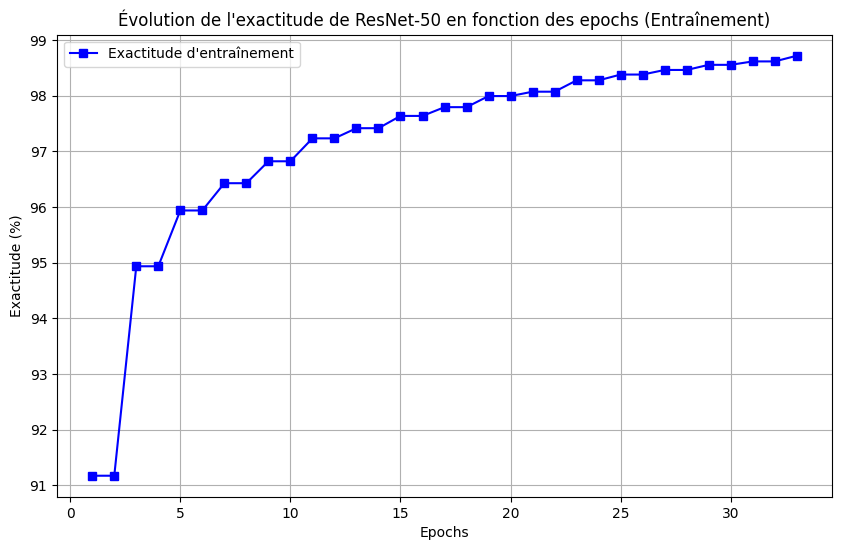

Validating:   0%|          | 0/344 [00:00<?, ?it/s]

Validation -> Acc: 97.98% | Precision: 96.61% | Recall: 98.46% | F1: 0.9752


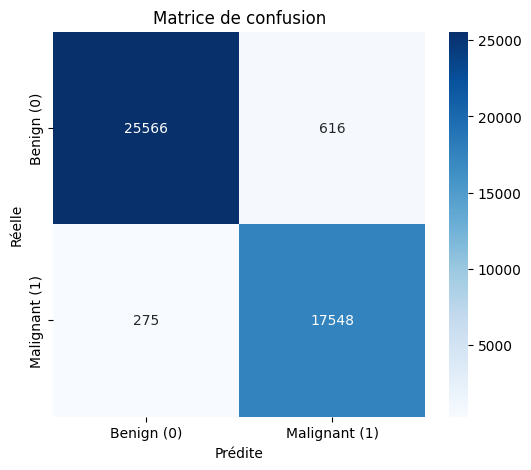

Epoch [17/30] Train Loss: 0.0355 | Train Acc: 98.72% | Val Acc: 97.98% 


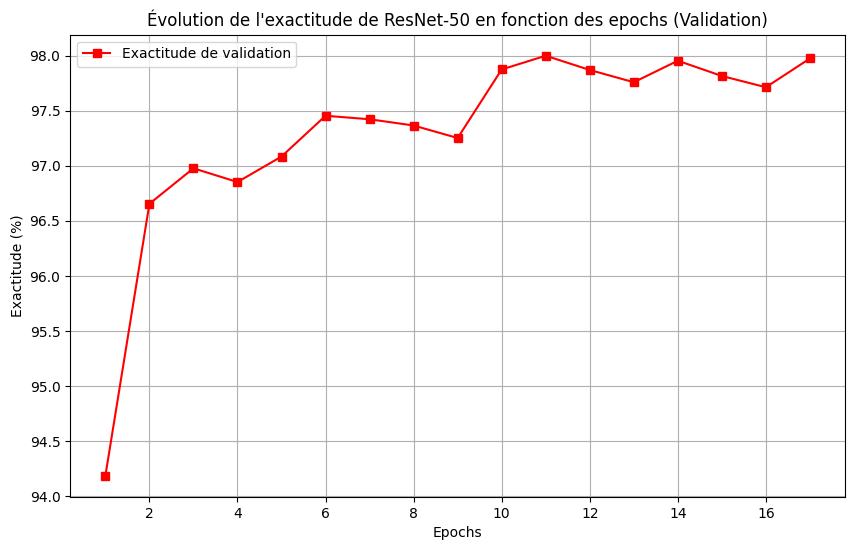

Training:   0%|          | 0/1376 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f852b77aa20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f852b77aa20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

RuntimeError: DataLoader worker (pid 6471) is killed by signal: Aborted. 

^^

^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f852b77aa20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1647, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f852b77aa20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1664, in __del__
    self._shutdown_workers()
  File "/usr/local

In [ ]:
EPOCHS = 30  # increase later

train_acc_history = []
val_acc_history = []
best_val_acc = 0

for epoch in range(EPOCHS):
      
    train_loss, train_acc = train_one_epoch(model, train_loader)
    # Display training graph
    train_acc_history.append(train_acc * 100)
    plot_training_accuracy(train_acc_history)

    val_acc = validate(model, val_loader)
    
    # Save history for accuracy graph
    train_acc_history.append(train_acc * 100)
    val_acc_history.append(val_acc * 100)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | "
          f"Train Acc: {train_acc*100:.2f}% | "
          f"Val Acc: {val_acc*100:.2f}% ")
    
    # Display validation graph
    plot_validation_accuracy(val_acc_history)
    
    # Save model only if validation accuracy improves
    if val_acc > best_val_acc:
          best_val_acc = val_acc
          torch.save(model.state_dict(), "./claris_resnet-50.pth")
          print(f"✓ Model saved with {val_acc*100:.2f}% accuracy")


## Utility: Model Cleaner

In [ ]:
# Used to reset models to their very first state

import os
import glob

files = glob.glob("./claris*.pth")

for f in files: 
    try:
        os.remove(f)
        print(f"Removed {f}")
    except OSError as e:
        print(f"Error while deleting {f} : returned {e.strerror}")
